---
title: Project 3 — Diode I–V Characterization
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

**Problem 1** solves a nonlinear diode circuit equation over a range of source voltages.
**Problem 2** estimates the diode ideality factor $n$ from measured I–V data via nonlinear least squares.


In [1]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - Project 3: project3.py
# Mark Khusid
##########################################################################################

##########################################################################################
# Project 3
##########################################################################################


## Problem 1


### Import Libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize


### Define Constants


In [3]:
# Constants
Is = 1e-9 # A
n = 1.7
R = 11e3 # Ohms
T = 350 # K
q = 1.6021766208e-19 # Coulombs
k = 1.380648e-23 # J/K


### Define Diode Equation


In [4]:
def diode_equation(Vd, V, Is, n, R, T):
    return Is * R * (np.exp(q * Vd / (n * k * T)) - 1) + Vd - V


### Define Source Voltage Range


In [5]:
source_voltages = np.arange(0.1, 2.5 + 0.1, 0.1)


### Create Results Lists


In [6]:
diode_voltages = []
diode_currents = []


### Define Initial Guess


In [7]:
guess = 0.7 # V


### Main Optimization Loop


In [8]:
for V in source_voltages:
    Vd_solution = optimize.fsolve(
        diode_equation,
        guess,
        args=(V, Is, n, R, T)
    )[0]

    I_solution = Is * (np.exp(q * Vd_solution / (n * k * T)) - 1)

    diode_voltages.append(Vd_solution)
    diode_currents.append(I_solution)

    guess = Vd_solution   # use previous solution as next guess


### Convert Results lists into NumPy Arrays


In [9]:
diode_voltages = np.array(diode_voltages)
diode_currents = np.array(diode_currents)


### Generate Plot


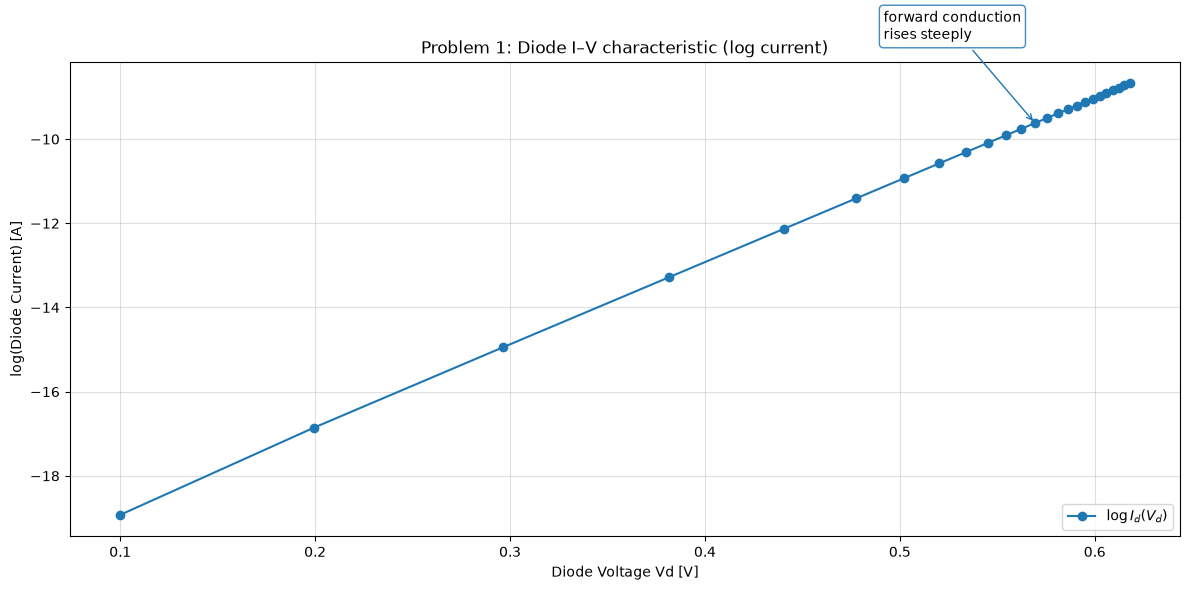

Vd range: [0.0999, 0.6178] V
Id range: [6.022e-09, 1.711e-04] A


In [10]:
plt.figure(figsize=(12, 6))
plt.plot(diode_voltages, np.log(diode_currents), marker="o", lw=1.5, label=r"$\log I_d(V_d)$")
plt.xlabel("Diode Voltage Vd [V]")
plt.ylabel("log(Diode Current) [A]")
plt.title("Problem 1: Diode I–V characteristic (log current)")
plt.grid(True, which="both", alpha=0.4)
# Annotate near mid-range if data exist
if len(diode_voltages) > 5:
    mid = len(diode_voltages) // 2
    plt.annotate(
        "forward conduction\nrises steeply",
        xy=(diode_voltages[mid], np.log(diode_currents[mid])),
        xytext=(diode_voltages[mid] - 0.15 * (diode_voltages.max()-diode_voltages.min()+1e-9),
                np.log(diode_currents[mid]) + 2),
        arrowprops=dict(arrowstyle="->", color="C0"),
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="C0"),
    )
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"Vd range: [{diode_voltages.min():.4f}, {diode_voltages.max():.4f}] V")
print(f"Id range: [{diode_currents.min():.3e}, {diode_currents.max():.3e}] A")


## Problem 2


### Algorithm


Given n

For every source voltage in dataset:

    Compute Is

    Use fsolve to find Vd

    Use Vd to compute I

Collect all predicted currents

Return predicted current array


### Import Libraries


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize


### Define Constants Specific to Problem 2


In [12]:
# Constants for Problem 2
K = 1.380648e-23
Q = 1.6021766208e-19
R = 1150
phi = 0.89
P2_AREA = 1e-8
P2_T = 375


### Define sat_current() Function


In [13]:
def sat_current(area, temp, phi):
    """
    Calculate the saturation current (thermionic emission current) 
    based on the Richardson-Dushman equation.
    
    This function computes the saturation current Is (often denoted as I0 
    in diode models or thermionic emission contexts) for a surface 
    emitting electrons at a given temperature.
    
    Physical Basis:
    The Richardson-Dushman equation for thermionic current density J is:
        J = A * T² * exp(-φ / (kT))
    where:
        A   = Richardson constant (material-dependent)
        T   = absolute temperature (K)
        φ   = work function (eV)
        k   = Boltzmann constant
    
    Multiplying by area gives the total current:
        I_s = area * A_eff * T² * exp(-φ * q / (k * T))
    
    In this implementation, the effective Richardson constant (A) is 
    absorbed into the 'area' parameter (or passed as a pre-multiplied value).
    
    Parameters
    ----------
    area : float or np.ndarray
        Effective emitting area (in m²) multiplied by the Richardson constant,
        or just the physical area if A is handled externally.
        Units: typically cm² or m² depending on how A is defined.
    
    temp : float or np.ndarray
        Absolute temperature in Kelvin (K). Must be > 0.
    
    phi : float or np.ndarray
        Work function φ (in eV or Joules, depending on units of Q and K).
        This is the energy barrier electrons must overcome.
    
    Returns
    -------
    float or np.ndarray
        Saturation current I_s (in Amperes, assuming consistent SI units).
        Same shape as the input arrays if vectorized inputs are provided.
    
    Notes
    -----
    - This is a simplified form. Real devices (e.g., vacuum tubes, Schottky diodes,
      or thermionic emitters) may include additional correction factors 
      (e.g., Schottky effect, temperature-dependent A, etc.).
    - For numerical stability at low temperatures, the exponential term can 
      become extremely small (underflow to zero) — this is physically expected.
    - Ensure consistent units:
        * Q is typically elementary charge q = 1.60217662e-19 C
        * K is Boltzmann constant k = 1.380649e-23 J/K
        * If phi is in eV, use k in eV/K (≈ 8.617333262145e-5 eV/K) and adjust Q accordingly.
    - Vectorized: Works with NumPy arrays for temperature sweeps, etc.
    
    Example Usage
    -------------
    >>> import numpy as np
    >>> Q = 1.60217662e-19  # C
    >>> K = 1.380649e-23    # J/K
    >>> area = 1e-4          # 1 cm² example
    >>> temp = 1000.0        # K
    >>> phi = 2.0            # eV (convert units if needed)
    >>> print(sat_current(area, temp, phi))
    """
    # Input validation (recommended addition for robustness)
    if np.any(temp <= 0):
        raise ValueError("Temperature must be positive (Kelvin).")
    
    # Core computation: Richardson-Dushman saturation current
    # area * T² * exp(- (phi * Q) / (K * T) )
    exponent = -phi * Q / (K * temp)          # Compute the exponent carefully to avoid overflow
    return area * temp**2 * np.exp(exponent)


### Define diode_equation() Function


In [14]:
def diode_equation(Vd, Vs, n, R, Is, temp):
    """
    Residual function for the Shockley diode equation with a series resistor.
    
    This implements the transcendental equation that arises when a real diode
    (modeled by the Shockley equation) is connected in series with a resistor R
    and driven by a voltage source Vs.
    
    Physical Context:
        The current through the diode is:
            Id = Is * (exp(q * Vd / (n * k * T)) - 1)
        
        Kirchhoff's Voltage Law (KVL) around the loop gives:
            Vs = Vd + Id * R
        
        Rearranged into residual form f(Vd) = 0:
            f(Vd) = Is * R * (exp(q * Vd / (n * k * T)) - 1) + Vd - Vs
    
    This residual is typically passed to a numerical root finder (e.g. scipy.optimize.fsolve,
    Newton-Raphson, or bisection) to solve for the diode voltage Vd.
    
    Parameters
    ----------
    Vd : float or np.ndarray
        Diode voltage drop (volts). This is the independent variable being solved for.
    
    Vs : float or np.ndarray
        Source voltage / applied voltage across the diode + resistor combination (volts).
    
    n : float
        Ideality factor (emission coefficient). Typically 1 for ideal diodes,
        1–2 for real silicon diodes, higher for other materials or non-ideal behavior.
    
    R : float
        Series resistance (ohms). Includes external resistor + any parasitic resistance.
    
    Is : float
        Saturation (reverse) current of the diode (amperes). Very small value,
        e.g. 1e-12 to 1e-9 A for small-signal diodes. Often temperature-dependent.
    
    temp : float or np.ndarray
        Junction temperature in Kelvin (K). Usually 300 K (room temp) unless specified.
    
    Returns
    -------
    float or np.ndarray
        Residual value f(Vd). The root (where residual == 0) gives the physical solution for Vd.
        Same shape as inputs when using arrays (vectorized operation).
    
    Notes
    -----
    - For numerical stability, especially with large forward bias, watch for overflow
      in the exponential term. Consider using np.exp with clipping or log-sum-exp tricks
      in production code.
    - Units must be consistent (SI: volts, amperes, ohms, Kelvin).
    - This equation is nonlinear and transcendental — no closed-form algebraic solution.
      Common solving methods:
        * scipy.optimize.fsolve
        * scipy.optimize.root_scalar (brentq, etc.)
        * Custom Newton-Raphson with derivative (f' is easy to compute analytically)
    - Temperature dependence: Both Is and the thermal voltage Vt = n*k*T/q are temperature sensitive.
    - This matches well with your recent work on numerical methods and Python-based circuit solutions.
    
    Example Usage
    -------------
    >>> from scipy.optimize import fsolve
    >>> Q = 1.60217662e-19
    >>> K = 1.380649e-23
    >>> Vs = 5.0
    >>> R = 1000.0
    >>> Is = 1e-12
    >>> n = 1.0
    >>> temp = 300.0
    >>>
    >>> # Solve for Vd
    >>> Vd_guess = 0.7
    >>> Vd_solution = fsolve(diode_equation, Vd_guess, args=(Vs, n, R, Is, temp))
    >>> print(Vd_solution[0])
    """
    # Compute thermal voltage component once (for clarity and minor efficiency)
    thermal_voltage = n * K * temp / Q          # Vt = n * k * T / q
    
    # Shockley diode current * R + diode voltage - source voltage
    diode_current_term = Is * R * (np.exp(Vd / thermal_voltage) - 1.0)
    
    return diode_current_term + Vd - Vs


### Define solve_current() Function


In [15]:
def solve_current(Vs, n, R, phi, area, temp, guess=0.7):
    """
    Solve for diode voltage Vd and current I in a diode + series resistor circuit.
    
    This is a complete solver that combines:
        1. Calculation of saturation current Is (thermionic / Shockley)
        2. Numerical solution of the nonlinear diode + resistor equation
        3. Final current computation
    
    It finds the operating point of a real diode driven by voltage Vs through resistor R.
    
    Workflow:
        Is = sat_current(area, temp, phi)
        Solve f(Vd) = 0  where f is diode_equation(...)
        Then I = Is * (exp(q*Vd/(n*k*T)) - 1)
    
    Parameters
    ----------
    Vs : float
        Applied source voltage (V).
    
    n : float
        Diode ideality factor (typically 1.0 - 2.0).
    
    R : float
        Series resistance (Ω).
    
    phi : float
        Work function or related barrier potential (consistent with sat_current units).
    
    area : float
        Effective area used in saturation current calculation (m² or cm²).
    
    temp : float
        Temperature in Kelvin (K).
    
    guess : float, optional
        Initial guess for diode voltage Vd (V). Default 0.7 V is a good starting
        point for silicon diodes in forward bias.
    
    Returns
    -------
    Vd : float
        Solved diode junction voltage drop (V).
    
    I : float
        Current through the diode and resistor (A).
    
    Notes
    -----
    - This function ties together the two previous functions you shared:
        - `sat_current(...)` for Is
        - `diode_equation(...)` as the residual for fsolve
    - Numerically robust for most forward-bias cases. For reverse bias or very
      large Vs, you may need to adjust the guess or add bounds.
    - Convergence: fsolve uses MINPACK's hybrd algorithm. It is generally fast
      and reliable when the initial guess is reasonable.
    - Vectorization: For I-V curve generation, wrap this in a loop or use
      np.vectorize (with care) or rewrite using array-friendly solvers.
     
    Example Usage
    -------------
    >>> Vs = 5.0
    >>> n = 1.1
    >>> R = 1000.0
    >>> phi = 0.7          # approximate barrier
    >>> area = 1e-8        # small diode area example
    >>> temp = 300.0
    >>>
    >>> Vd, I = solve_current(Vs, n, R, phi, area, temp)
    >>> print(f"Diode voltage: {Vd:.4f} V, Current: {I*1000:.2f} mA")
    """
    
    # Step 1: Compute temperature-dependent saturation current
    Is = sat_current(area, temp, phi)
    
    # Step 2: Numerically solve for diode voltage Vd
    # fsolve returns an array; we extract the scalar result [0]
    Vd = optimize.fsolve(                    # Note: should be fsolve, assuming imported
        diode_equation,
        guess,
        args=(Vs, n, R, Is, temp)
    )[0]
    
    # Step 3: Compute the actual diode current using Shockley equation
    # (equivalent to (Vs - Vd) / R by KVL, but computed directly for consistency)
    exponent = Q * Vd / (n * K * temp)
    I = Is * (np.exp(exponent) - 1.0)
    
    return Vd, I


### Define calc_currents() Function


In [16]:
def calc_currents(n, R, phi, area, temp, source_v):
    """
    Compute diode currents for an array of source voltages (I-V curve generation).
    
    This is a high-level wrapper that:
        - Loops over multiple applied voltages (Vs)
        - Uses the previously defined `solve_current` solver for each point
        - Employs **continuation** (warm-starting the solver with the previous Vd)
          to improve convergence speed and reliability
    
    Ideal for generating synthetic I-V characteristics of a diode + series resistor
    circuit, useful for model validation, homework plots, or comparison with
    ngspice simulations.
    
    Parameters
    ----------
    n : float
        Diode ideality factor.
    
    R : float
        Series resistance (Ω).
    
    phi : float
        Work function / barrier height (consistent with sat_current).
    
    area : float
        Effective emitting area (consistent with sat_current).
    
    temp : float
        Temperature in Kelvin (K).
    
    source_v : array-like
        Array or list of source voltages Vs to sweep (volts).
        Typically from 0 V up to several volts for forward bias.
    
    Returns
    -------
    np.ndarray
        Array of calculated diode currents (A) corresponding to each Vs.
        Shape matches the length of source_v.
    
    Notes
    -----
    - **Continuation method**: By updating `guess = Vd` after each solve, the
      initial guess for the next point is much closer to the true solution.
      This dramatically improves speed and robustness, especially near the
      knee of the diode curve.
    
    - Performance: Suitable for hundreds to a few thousand points. For very
      large sweeps, consider vectorized alternatives or faster root-finding
      (e.g., custom Newton-Raphson).
    
    - Physical insight: At low Vs the current is near zero (leakage). As Vs
      increases, the diode turns on and current rises exponentially until
      limited by the series resistor R.
    
    - Related functions (this completes the stack you shared):
        1. sat_current(...)          → Is
        2. diode_equation(...)       → residual for solver
        3. solve_current(...)        → single-point solver
        4. calc_currents(...)        → multi-point sweep (current function)
    
    Example Usage
    -------------
    >>> import numpy as np
    >>> Vs_sweep = np.linspace(0, 5, 200)          # 200 points from 0V to 5V
    >>> n = 1.05
    >>> R = 470.0
    >>> phi = 0.7
    >>> area = 1e-8
    >>> temp = 300.0
    >>>
    >>> currents = calc_currents(n, R, phi, area, temp, Vs_sweep)
    >>>
    >>> # Plotting (matplotlib)
    >>> import matplotlib.pyplot as plt
    >>> plt.plot(Vs_sweep, currents * 1000)   # mA
    >>> plt.xlabel('Source Voltage Vs (V)')
    >>> plt.ylabel('Diode Current (mA)')
    >>> plt.title('Diode I-V Characteristic')
    >>> plt.grid(True)
    >>> plt.show()
    
    Debugging / Verification Tips
    -----------------------------
    - Compare the output against ngspice simulation or measured lab data.
    - Uncomment the print statement inside the loop for detailed per-point output.
    - Check conservation: I should approximately equal (Vs - Vd)/R.
    """
    calc_i = []           # List to collect currents (more efficient than np.append)
    guess = 0.7           # Initial reasonable guess for silicon-like diodes
    
    for Vs in source_v:
        # Solve for this voltage using warm-started guess from previous point
        Vd, I = solve_current(Vs, n, R, phi, area, temp, guess)
        
        calc_i.append(I)
        
        # Update guess for next iteration (continuation method)
        guess = Vd
    
    # Optional: Print final operating point for the last Vs
    # print(f' [*] Final Vd: {Vd:.2f} V, Id: {I:.4e} A')
    
    return np.array(calc_i)


### Define opt_n() Function


In [17]:
def opt_n(n_value, R, phi_value, area, temp, src_v, meas_i):
    """
    Objective (residual) function for optimizing the diode ideality factor 'n'.
    
    This function is designed to be passed to SciPy optimizers (e.g. least_squares,
    curve_fit, or minimize) to fit the model parameter 'n' to measured I-V data.
    
    It computes the relative error between the model-predicted currents and
    the experimentally measured currents, which the optimizer then tries to minimize.
    
    Parameters
    ----------
    n_value : array-like of length 1
        Current guess for the ideality factor 'n' (passed by the optimizer).
        Extracted as scalar inside the function.
        Typical range: 1.0 (ideal) to 2.5+ for real diodes.
    
    R : float
        Fixed series resistance (Ω).
    
    phi_value : float
        Fixed work function / barrier height (consistent with sat_current).
    
    area : float
        Fixed effective area parameter.
    
    temp : float
        Fixed temperature in Kelvin.
    
    src_v : np.ndarray
        Array of source voltages (independent variable).
    
    meas_i : np.ndarray
        Measured (experimental) diode currents corresponding to src_v.
        Must have the same length as src_v.
    
    Returns
    -------
    np.ndarray
        Array of relative residuals (one per data point).
        Shape matches meas_i.
        The optimizer drives this array toward zero.
    
    Notes
    -----
    - **Relative error** is used: (calc - meas) / max(|meas|, 1e-14)
      This prevents division-by-zero at very small currents and gives more balanced
      weighting across decades of current (important for diode exponential behavior).
    
    - **Why n only?** Other parameters (R, phi, area, temp) are held fixed.
      You can extend this to optimize multiple parameters by adjusting the signature.
    
    - This completes a powerful fitting pipeline:
        sat_current → diode_equation → solve_current → calc_currents → opt_n
    
    - Optimization Tips:
        * Use `scipy.optimize.least_squares` for bound constraints on n (e.g. [1.0, 3.0]).
        * Good initial guess for n is usually 1.5–2.0.
        * If fitting fails, try different bounds, scaling, or loss functions ('soft_l1').
    
    Example Usage
    -------------
    >>> from scipy.optimize import least_squares
    >>>
    >>> # Assume you have measured data
    >>> src_v = np.array([...])      # your voltage sweep
    >>> meas_i = np.array([...])     # measured currents
    >>>
    >>> # Fixed parameters
    >>> R = 1000.0
    >>> phi_value = 0.7
    >>> area = 1e-8
    >>> temp = 300.0
    >>>
    >>> # Run optimization
    >>> result = least_squares(
    ...     opt_n,
    ...     x0=[1.5],                     # initial guess for n
    ...     args=(R, phi_value, area, temp, src_v, meas_i),
    ...     bounds=([1.0], [3.0])
    ... )
    >>>
    >>> best_n = result.x[0]
    >>> print(f"Optimized ideality factor n = {best_n:.4f}")
    >>> print(f"Cost: {result.cost:.2e}")
    """
    # Extract scalar from optimizer's array input
    n_value = n_value[0]
    
    # Compute model currents for the current guess of 'n'
    calc_i = calc_currents(n_value, R, phi_value, area, temp, src_v)
    
    # Relative residual vector (robust against near-zero currents)
    # Using np.maximum avoids division by zero and reduces sensitivity to tiny currents
    err_array = (calc_i - meas_i) / np.maximum(np.abs(meas_i), 1e-14)
    
    return err_array


### Load Diode Test Data into Memory


In [18]:
data = np.loadtxt("DiodeIV.txt", dtype=np.float64)
source_v = data[:, 0]
meas_diode_i = data[:, 1]


### Define List of Initial Guesses


In [19]:
# Try multiple initial guesses
initial_guesses = [1.0, 1.5, 2.0, 3.0]


### Main Outer Optimization Loop


In [20]:
for n_init in initial_guesses:
    n_opt_array = optimize.leastsq(
        opt_n,
        [n_init],
        args=(R, phi, P2_AREA, P2_T, source_v, meas_diode_i)
    )

    n_opt = n_opt_array[0][0]
    print(f"Initial guess: {n_init}, optimum n: {n_opt}")


Initial guess: 1.0, optimum n: 1.070000000000017
Initial guess: 1.5, optimum n: 1.070000000000017
Initial guess: 2.0, optimum n: 1.070000000000017


Initial guess: 3.0, optimum n: 1.0700000000000118


### Calculate Diode Current Given Found Optimum Value for n


In [21]:
# Use final n_opt for plotting
calc_diode_i = calc_currents(n_opt, R, phi, P2_AREA, P2_T, source_v)


### Generate Plots


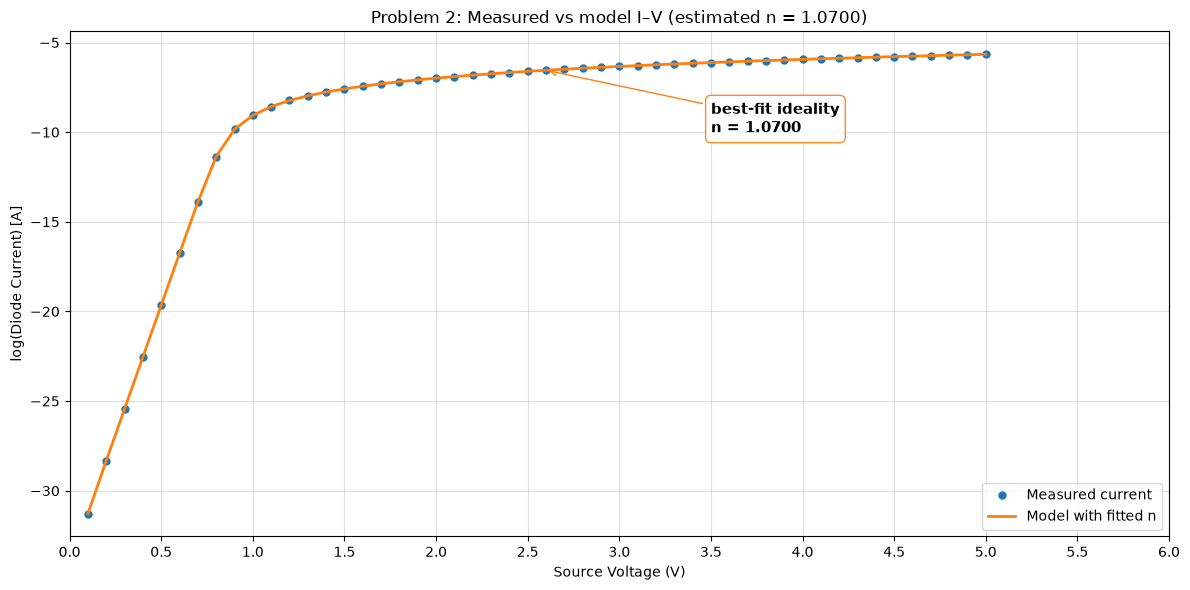

Optimum ideality factor n = 1.070000
log-current residual RMS = 0.0000


In [22]:
plt.figure(figsize=(12, 6))
plt.plot(source_v, np.log(meas_diode_i), "o", label="Measured current", markersize=5)
plt.plot(source_v, np.log(calc_diode_i), "-", label="Model with fitted n", lw=2)
plt.xlabel("Source Voltage (V)")
plt.ylabel("log(Diode Current) [A]")
plt.title(f"Problem 2: Measured vs model I–V (estimated n = {n_opt:.4f})")
plt.grid(True, which="both", alpha=0.4)
plt.xlim(0, 6)
plt.xticks(np.arange(0, 6.5, 0.5))
# Keep annotation inside axes
plt.annotate(
    f"best-fit ideality\nn = {n_opt:.4f}",
    xy=(float(source_v[len(source_v)//2]), float(np.log(calc_diode_i[len(source_v)//2]))),
    xytext=(3.5, -10),
    arrowprops=dict(arrowstyle="->", color="C1"),
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="C1", alpha=0.9),
)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"Optimum ideality factor n = {n_opt:.6f}")
resid = np.log(meas_diode_i) - np.log(calc_diode_i)
print(f"log-current residual RMS = {np.sqrt(np.mean(resid**2)):.4f}")
